# 01 - EDA: Video Game Sales
Análise exploratória do dataset de vendas de jogos de videogame.
Objetivo: praticar filtragem, agrupamento e visualização com pandas.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/vgsales.csv')
print(df.shape) # .shape retorna um tupla (linha,coluna)
print(df.head()) # retorna as 5 primeiras linhas do DataFrame

(16598, 11)
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


## Nível 1 — Exploração básica

### Quantas linhas e colunas tem o dataset? Quais são os tipos de cada coluna?
#### → .shape, .dtypes, .info()

In [ ]:
total_linha_col = df.shape # retorna um tupla (linha,coluna)
print(total_linha_col)

In [ ]:
tipo_col = df.dtypes # retorna o tipo de cada coluna
print(tipo_col)

In [ ]:
info_col = df.info()
print(info_col) # Retorna um resumo do DataFrame

### Quantos valores nulos existem em cada coluna? Qual coluna tem mais nulos?
#### → .isnull().sum()

In [ ]:
tot_null = df.isnull().sum()
print('Total de Nulos por coluna:', tot_null)
# .isnull() retorna um DataFrame onde os valores sao trocados por booleanos, True para Nulos e False para nao Nulos
# .sum() soma os valores de cada coluna (por padrão) e retorna uma Series contendo a soma de cada coluna.

Total de Nulos por coluna: Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64



### Quais são os 10 jogos com maior venda global de todos os tempos?
#### → .sort_values(), .head(10)

In [60]:
top_10_jogos = df.sort_values(by='Global_Sales', ascending=False).head(10)  
top_10_jogos
# sort_values por padrão ordena do menor para o maior.

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


### Quantos gêneros únicos existem? Liste todos eles.
#### → .nunique(), .unique()

In [61]:
list(df.columns)
unique_genres = df['Genre'].unique() # Quais valores existem na coluna? (Action, Sports, RPG, etc.)
qtd_unique_genres = df['Genre'].nunique() # Quantos valores diferentes existem na coluna?

print('Generos unicos:')
print(unique_genres)
print('Qtd de valores unicos:', qtd_unique_genres)

Generos unicos:
<StringArray>
[      'Sports',     'Platform',       'Racing', 'Role-Playing',
       'Puzzle',         'Misc',      'Shooter',   'Simulation',
       'Action',     'Fighting',    'Adventure',     'Strategy']
Length: 12, dtype: str
Qtd de valores unicos: 12


## Nível 2 — Filtragem e agrupamento

### Filtre apenas os jogos do gênero "Action" lançados depois de 2010. Quantos são?
#### → df[ (condição1) & (condição2) ]

In [21]:
df[(df['Genre'] == 'Action') & (df['Year'] > 2010)]
# o primeiro df[] é o DataFrame que quero que me retorne se as condicoes (df['Genre'] == 'Action') & (df['Year'] > 2010)
# forem verdadeiras

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16,17,Grand Theft Auto V,PS3,2013.0,Action,Take-Two Interactive,7.01,9.27,0.97,4.14,21.40
23,24,Grand Theft Auto V,X360,2013.0,Action,Take-Two Interactive,9.63,5.31,0.06,1.38,16.38
44,45,Grand Theft Auto V,PS4,2014.0,Action,Take-Two Interactive,3.80,5.81,0.36,2.02,11.98
82,83,FIFA Soccer 13,PS3,2012.0,Action,Electronic Arts,1.06,5.05,0.13,2.01,8.24
115,116,Uncharted 3: Drake's Deception,PS3,2011.0,Action,Sony Computer Entertainment,2.77,2.80,0.19,1.06,6.83
...,...,...,...,...,...,...,...,...,...,...,...
16546,16549,Hyakki Yagyou Kaidan Romance,PSP,2012.0,Action,Quinrose,0.00,0.00,0.01,0.00,0.01
16548,16551,Hakuoki: Reimeiroku - Omouhase Kara,PSV,2015.0,Action,Idea Factory,0.00,0.00,0.01,0.00,0.01
16550,16553,God Eater Off Shot: Tachibana Sakuya-hen Twin ...,PS4,2016.0,Action,Namco Bandai Games,0.00,0.00,0.01,0.00,0.01
16567,16570,Fujiko F. Fujio Characters: Great Assembly! Sl...,3DS,2014.0,Action,Namco Bandai Games,0.00,0.00,0.01,0.00,0.01


### Qual gênero vendeu mais globalmente no total? Monte um ranking dos gêneros por Global_Sales.
#### → .groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

In [28]:
best_seller = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
best_seller

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64

### Qual plataforma tem a maior média de vendas por jogo? (não total — média por jogo)
#### → .groupby()[ ].mean().sort_values(ascending=False)

In [33]:
df.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False).head()

Platform
GB      2.606633
NES     2.561939
GEN     1.050370
SNES    0.837029
PS4     0.827679
Name: Global_Sales, dtype: float64

### Compare as vendas totais por região (NA, EU, JP, Other). Qual região compra mais jogos?
#### → df[[ , , , ]].sum()

In [ ]:
df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64

### Para cada gênero, calcule a porcentagem de vendas que vem do Japão. Qual gênero é mais "japonês"?
#### → Crie uma nova coluna, depois .groupby()[ ].mean().sort_values(ascending=False)

In [ ]:
df['JP_Percentage_Sales'] = df['JP_Sales'] / df['Global_Sales']

In [62]:
df.groupby('Genre')['JP_Percentage_Sales'].mean().sort_values(ascending=False)

Genre
Adventure       0.524895
Role-Playing    0.495762
Fighting        0.348764
Strategy        0.333266
Misc            0.254494
Simulation      0.217944
Action          0.201709
Puzzle          0.174798
Sports          0.167076
Platform        0.121121
Shooter         0.084727
Racing          0.059710
Name: JP_Percentage_Sales, dtype: float64

## Nível 3 — Visualização

### Faça um gráfico de barras com as vendas globais totais por gênero, do maior para o menor.
#### → .plot(kind= )

In [6]:
tot_global_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
tot_global_sales

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64

<Axes: xlabel='Genre'>

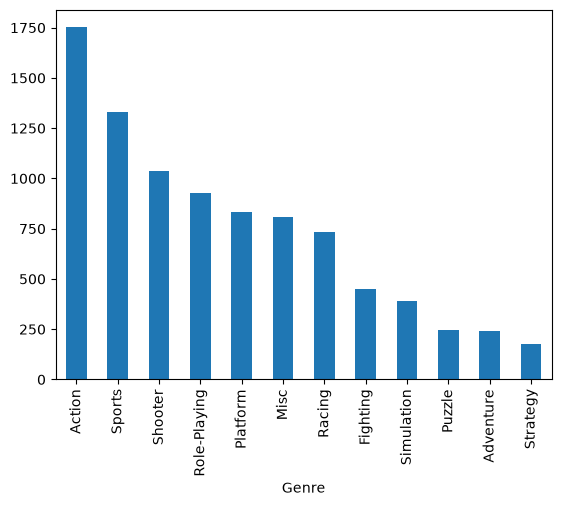

In [12]:
tot_global_sales.plot(kind='bar')

### Faça um gráfico de linha mostrando a evolução das vendas globais por ano, de 1990 a 2016.
#### → .groupby()[ ].sum().plot(kind= )

In [44]:
annual_global_sales = df.groupby('Year')['Global_Sales'].sum()

<Axes: title={'center': 'Vendas Globais por Ano'}, xlabel='Ano', ylabel='Vendas (milhões)'>

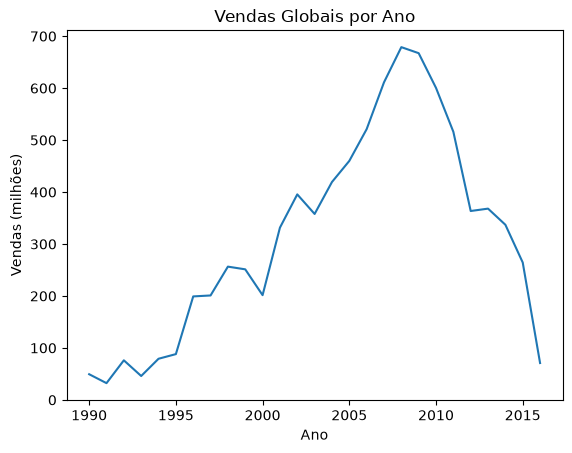

In [58]:
annual_global_sales.loc[1990 : 2016].plot(kind='line', title='Vendas Globais por Ano', xlabel='Ano', ylabel='Vendas (milhões)')

### Crie um gráfico de barras empilhadas mostrando NA vs EU vs JP vs Other para os 5 gêneros mais vendidos.
#### → .plot(kind= , stacked= )

In [63]:
country_sales_by_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum().sort_values(by='NA_Sales', ascending=False).head()

<Axes: xlabel='Genre'>

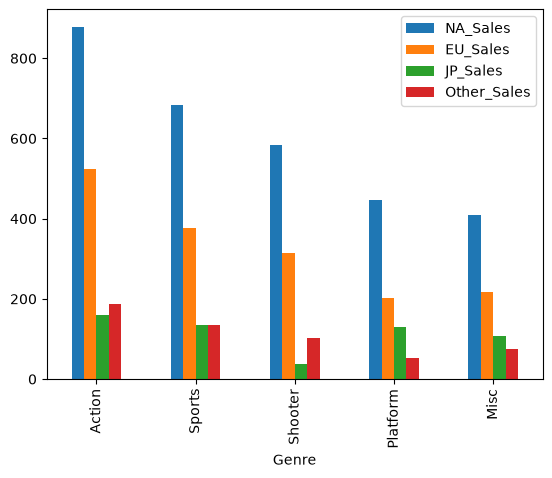

In [62]:
country_sales_by_genre.plot(kind='bar')

### Encontre o jogo mais vendido de cada gênero. Resultado: um DataFrame com uma linha por gênero.
#### → .groupby().apply(lambda x: x.nlargest( , ))

In [ ]:
df.groupby('Genre').apply(lambda x: x.nlargest(1, 'Global_Sales'))

TypeError: '<=' not supported between instances of 'str' and 'int'

In [64]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01
